# Food catalog cleaning & de-duplication EDA

Explore whether **`usda.food_4_portion_data`** (4 core macros + density-inferable volume portion) needs extra **text cleaning** or **de-duplication** before ingredient matching.

Also compares:
- **`food_mvp`** — non-branded + any nutrient + volume portion (current matcher catalog)
- **`food_nutrient_data`** — any food with ≥1 `food_nutrient` row (broader; heavy branded in full loads)

Normalization for duplicates uses the same `normalize_text()` as [`scripts/ingredient_match.py`](../scripts/ingredient_match.py) (`FoodMatcher`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rapidfuzz import fuzz, process

ROOT = Path.cwd().resolve()
if ROOT.name == "scratch":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from db import connect
from food_name_prefixes import words_before_delimiters
from ingredient_match import normalize_text

pd.set_option("display.max_colwidth", 120)

## 1. Catalog sizes

In [2]:
CATALOG_SQL = """
SELECT 'food_4_portion_data' AS view_name, data_type, COUNT(*) AS n
FROM usda.food_4_portion_data
GROUP BY 1, 2
UNION ALL
SELECT 'food_mvp', data_type, COUNT(*)
FROM usda.food_mvp
GROUP BY 1, 2
UNION ALL
SELECT 'food_nutrient_data', data_type, COUNT(*)
FROM usda.food_nutrient_data
GROUP BY 1, 2
ORDER BY 1, 3 DESC
"""

with connect() as conn:
    catalog_counts = pd.read_sql(CATALOG_SQL, conn)
    f4 = pd.read_sql(
        "SELECT fdc_id, data_type, description, food_category_id, publication_date "
        "FROM usda.food_4_portion_data",
        conn,
    )
    mvp = pd.read_sql("SELECT fdc_id, data_type, description FROM usda.food_mvp", conn)

pivot = catalog_counts.pivot_table(
    index="data_type", columns="view_name", values="n", fill_value=0, aggfunc="sum"
)
pivot["total_in_views"] = pivot.sum(axis=1)
display(pivot.sort_values("total_in_views", ascending=False))
print(f"food_4_portion_data rows loaded: {len(f4):,}")

/var/folders/qq/pmrcg6p90876k5_k2lxpk37w0000gn/T/ipykernel_16177/170822762.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  catalog_counts = pd.read_sql(CATALOG_SQL, conn)
/var/folders/qq/pmrcg6p90876k5_k2lxpk37w0000gn/T/ipykernel_16177/170822762.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  f4 = pd.read_sql(
/var/folders/qq/pmrcg6p90876k5_k2lxpk37w0000gn/T/ipykernel_16177/170822762.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  mvp = pd.read_sql("SELECT fdc_id, data_type, description FROM usda.food_mvp", c

view_name,food_4_portion_data,food_mvp,food_nutrient_data,total_in_views
data_type,,,,
branded_food,0,0,128110,128110
sr_legacy_food,3321,3321,7793,14435
sub_sample_food,0,0,8438,8438
agricultural_acquisition,0,0,810,810
foundation_food,37,38,92,167


food_4_portion_data rows loaded: 3,358


## 2. Text quality (missing / length / punctuation)

,metric,food_4_portion_data
0,rows,3358.0
1,empty description,0.0
2,empty norm (after FoodMatcher clean),0.0
3,description != norm (case/punct changed),3310.0
4,has punctuation,3310.0
5,has digits,162.0
6,median description length,46.0


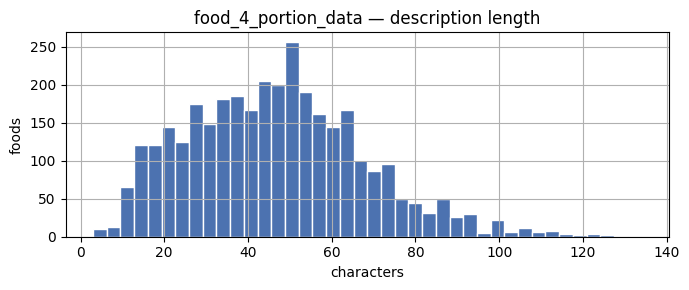

In [3]:
def prep_descriptions(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["description"] = out["description"].fillna("").astype(str)
    out["norm"] = out["description"].map(normalize_text)
    out["desc_len"] = out["description"].str.len()
    out["norm_len"] = out["norm"].str.len()
    out["has_upper"] = out["description"].str.contains(r"[A-Z]", regex=True, na=False)
    out["has_digit"] = out["description"].str.contains(r"\d", regex=True, na=False)
    out["has_punct"] = out["description"].str.contains(r"[^\w\s]", regex=True, na=False)
    return out


f4 = prep_descriptions(f4)
mvp = prep_descriptions(mvp)

quality = pd.DataFrame(
    {
        "metric": [
            "rows",
            "empty description",
            "empty norm (after FoodMatcher clean)",
            "description != norm (case/punct changed)",
            "has punctuation",
            "has digits",
            "median description length",
        ],
        "food_4_portion_data": [
            len(f4),
            (f4["description"] == "").sum(),
            (f4["norm"] == "").sum(),
            (f4["description"].str.casefold() != f4["norm"]).sum(),
            f4["has_punct"].sum(),
            f4["has_digit"].sum(),
            f4["desc_len"].median(),
        ],
    }
)
display(quality)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
f4["desc_len"].hist(bins=40, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("food_4_portion_data — description length")
ax.set_xlabel("characters")
ax.set_ylabel("foods")
plt.tight_layout()
plt.show()

## 3. Exact & normalized duplicate descriptions

Multiple `fdc_id` values with the same display text (or same `normalize_text`) create **ambiguous exact matches** for `FoodMatcher` and inflate candidate lists for fuzzy search.

In [4]:
def duplicate_summary(df: pd.DataFrame, key: str) -> pd.Series:
    sizes = df.groupby(key, dropna=False).size()
    dup_keys = sizes[sizes > 1]
    return pd.Series(
        {
            "unique_keys": sizes.shape[0],
            "keys_with_duplicates": dup_keys.shape[0],
            "rows_in_dup_groups": dup_keys.sum(),
            "extra_rows_vs_unique": int(dup_keys.sum() - dup_keys.shape[0]),
            "pct_rows_in_dup_groups": round(100 * dup_keys.sum() / len(df), 2),
        }
    )


dup_stats = pd.DataFrame(
    {
        "exact description": duplicate_summary(f4, "description"),
        "normalized (FoodMatcher)": duplicate_summary(f4, "norm"),
    }
).T
display(dup_stats)

norm_sizes = f4.groupby("norm").size()
dup_norms = norm_sizes[norm_sizes > 1].sort_values(ascending=False)
print(f"Top normalized strings with multiple fdc_id ({len(dup_norms)} groups):")
display(dup_norms.head(15).to_frame("n_fdc_ids"))

,unique_keys,keys_with_duplicates,rows_in_dup_groups,extra_rows_vs_unique,pct_rows_in_dup_groups
exact description,3327.0,31.0,62.0,31.0,1.85
normalized (FoodMatcher),3326.0,32.0,64.0,32.0,1.91


Top normalized strings with multiple fdc_id (32 groups):


,n_fdc_ids
norm,
beans snap green canned regular pack drained solids,2
broccoli raw,2
seeds sunflower seed kernels dry roasted with salt added,2
sauce salsa ready to serve,2
sauce pasta spaghetti marinara ready to serve,2
restaurant chinese fried rice without meat,2
pears raw bartlett includes foods for usda s food distribution program,2
peaches yellow raw,2
pancakes whole wheat dry mix incomplete,2


In [5]:
def show_dup_examples(df: pd.DataFrame, key: str, n_groups: int = 8) -> pd.DataFrame:
    sizes = df.groupby(key).size()
    keys = sizes[sizes > 1].sort_values(ascending=False).head(n_groups).index
    sample = df[df[key].isin(keys)].sort_values([key, "fdc_id"])
    cols = ["fdc_id", "data_type", "description", "food_category_id", "publication_date"]
    cols = [c for c in cols if c in sample.columns]
    return sample[cols + [key] if key not in cols else cols]


display(show_dup_examples(f4, "norm"))

,fdc_id,data_type,description,food_category_id,publication_date,norm
724,169143,sr_legacy_food,"Beans, snap, green, canned, regular pack, drained solids",11,2019-04-01,beans snap green canned regular pack drained solids
3324,321611,foundation_food,"Beans, snap, green, canned, regular pack, drained solids",11,2019-04-01,beans snap green canned regular pack drained solids
1362,170379,sr_legacy_food,"Broccoli, raw",11,2019-04-01,broccoli raw
3325,321900,foundation_food,"Broccoli, raw",11,2019-04-01,broccoli raw
1121,169928,sr_legacy_food,"Peaches, yellow, raw",9,2019-04-01,peaches yellow raw
3337,325430,foundation_food,"Peaches, yellow, raw",9,2019-04-01,peaches yellow raw
109,167776,sr_legacy_food,"Pears, raw, bartlett (Includes foods for USDA's Food Distribution Program)",9,2019-04-01,pears raw bartlett includes foods for usda s food distribution program
3353,332597,foundation_food,"Pears, raw, bartlett (Includes foods for USDA's Food Distribution Program)",9,2019-04-01,pears raw bartlett includes foods for usda s food distribution program
26,167668,sr_legacy_food,"Restaurant, Chinese, fried rice, without meat",25,2019-04-01,restaurant chinese fried rice without meat
3357,334536,foundation_food,"Restaurant, Chinese, fried rice, without meat",25,2019-04-01,restaurant chinese fried rice without meat


## 4. Duplicates within vs across `data_type`

In [6]:
def dup_cross_type(df: pd.DataFrame, key: str = "norm") -> pd.DataFrame:
    g = df.groupby(key).agg(
        n_fdc=("fdc_id", "count"),
        n_types=("data_type", "nunique"),
        types=("data_type", lambda s: ", ".join(sorted(s.unique()))),
    )
    g = g[g["n_fdc"] > 1].sort_values("n_fdc", ascending=False)
    return g


cross = dup_cross_type(f4)
within_only = cross[cross["n_types"] == 1]
across = cross[cross["n_types"] > 1]
print(f"Duplicate norm groups: {len(cross)} | same data_type only: {len(within_only)} | across types: {len(across)}")
if len(across):
    display(across.head(10))
else:
    print("(No cross-type duplicates in this load — expected when view is mostly sr_legacy_food.)")

Duplicate norm groups: 32 | same data_type only: 1 | across types: 31


,n_fdc,n_types,types
norm,,,
beans snap green canned regular pack drained solids,2,2,"foundation_food, sr_legacy_food"
broccoli raw,2,2,"foundation_food, sr_legacy_food"
seeds sunflower seed kernels dry roasted with salt added,2,2,"foundation_food, sr_legacy_food"
sauce salsa ready to serve,2,2,"foundation_food, sr_legacy_food"
sauce pasta spaghetti marinara ready to serve,2,2,"foundation_food, sr_legacy_food"
restaurant chinese fried rice without meat,2,2,"foundation_food, sr_legacy_food"
pears raw bartlett includes foods for usda s food distribution program,2,2,"foundation_food, sr_legacy_food"
peaches yellow raw,2,2,"foundation_food, sr_legacy_food"
oranges raw navels includes foods for usda s food distribution program,2,2,"foundation_food, sr_legacy_food"


## 5. `food_nutrient_data` — branded de-duplication pressure

On a full USDA load, **`food_nutrient_data`** includes ~128k+ branded rows. Many share normalized descriptions (variants, reformulations, regional SKUs). This section quantifies that separately from the matcher-ready `food_4_portion_data` slice.

In [14]:
NUTRIENT_SAMPLE_SQL = """
SELECT fdc_id, data_type, description
FROM usda.food_nutrient_data
"""

with connect() as conn:
    fnd = pd.read_sql(NUTRIENT_SAMPLE_SQL, conn)

fnd = prep_descriptions(fnd)

by_type = (
    fnd.groupby("data_type")
    .apply(lambda g: duplicate_summary(g, "norm"), include_groups=False)
    .unstack(0)
    .T
)
by_type["rows"] = fnd.groupby("data_type").size()
display(by_type.loc["rows"].sort_values(ascending=False))

branded = fnd[fnd["data_type"] == "branded_food"]
if len(branded):
    top_branded_dup = branded.groupby("norm").size()
    top_branded_dup = top_branded_dup[top_branded_dup > 1].sort_values(ascending=False).head(10)
    print("Top branded norms with most fdc_ids:")
    display(top_branded_dup.to_frame("n_fdc_ids"))

/var/folders/qq/pmrcg6p90876k5_k2lxpk37w0000gn/T/ipykernel_16177/987271691.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fnd = pd.read_sql(NUTRIENT_SAMPLE_SQL, conn)


data_type
    data_type
agricultural_acquisition       810
branded_food                128110
foundation_food                 92
s...
dtype: object

Top branded norms with most fdc_ids:


,n_fdc_ids
norm,
ice cream,267
soda,224
potato chips,210
cereal,144
premium ice cream,122
pasta sauce,106
milk chocolate,89
100 juice,87
pinto beans,85


## 6. Near-duplicate pairs (high WRatio, different `fdc_id`)

Strings that are *almost* the same but not identical after normalization — candidates for merge rules or canonical `fdc_id` picking.

In [15]:
WRATIO_NEAR = 92  # tune: 90–95
MAX_ROWS = 2500   # cap runtime on large catalogs

work = f4.sort_values("norm").drop_duplicates("norm", keep="first")
if len(work) > MAX_ROWS:
    work = work.sample(MAX_ROWS, random_state=0)

choices = work["norm"].tolist()
near_rows = []
seen_pairs: set[tuple[str, str]] = set()

for i, row in work.iterrows():
    q = row["norm"]
    if not q:
        continue
    hits = process.extract(q, choices, scorer=fuzz.WRatio, limit=4)
    for match_norm, score, _ in hits:
        if match_norm == q or score < WRATIO_NEAR:
            continue
        pair = tuple(sorted((q, match_norm)))
        if pair in seen_pairs:
            continue
        seen_pairs.add(pair)
        near_rows.append(
            {
                "norm_a": pair[0],
                "norm_b": pair[1],
                "wratio": score,
            }
        )

near = pd.DataFrame(near_rows).sort_values("wratio", ascending=False)
print(f"Near-duplicate norm pairs (WRatio ≥ {WRATIO_NEAR}, sample n={len(work)}): {len(near)}")
display(near.head(20))

Near-duplicate norm pairs (WRatio ≥ 92, sample n=2500): 614


,norm_a,norm_b,wratio
296,mung beans mature seeds cooked boiled without salt,mungo beans mature seeds cooked boiled without salt,99.009901
443,mung beans mature seeds cooked boiled with salt,mungo beans mature seeds cooked boiled with salt,98.947368
183,infant formula mead johnson enfamil premature 20 calories ready to feed low iron,infant formula mead johnson enfamil premature 24 calories ready to feed low iron,98.750000
501,apple juice frozen concentrate unsweetened diluted with 3 volume water with added ascorbic acid,apple juice frozen concentrate unsweetened diluted with 3 volume water without added ascorbic acid,98.445596
310,alcoholic beverage distilled all gin rum vodka whiskey 80 proof,alcoholic beverage distilled all gin rum vodka whiskey 90 proof,98.412698
180,alcoholic beverage distilled all gin rum vodka whiskey 90 proof,alcoholic beverage distilled all gin rum vodka whiskey 94 proof,98.412698
71,alcoholic beverage distilled all gin rum vodka whiskey 80 proof,alcoholic beverage distilled all gin rum vodka whiskey 86 proof,98.412698
405,rice white long grain regular cooked enriched with salt,rice white long grain regular cooked unenriched with salt,98.214286
224,mung beans mature seeds raw,mungo beans mature seeds raw,98.181818
484,squash summer crookneck and straightneck frozen cooked boiled drained with salt,squash summer crookneck and straightneck frozen cooked boiled drained without salt,98.136646


## 7. Leading spans before delimiters (`words_before_delimiters`)

`FoodMatcher` uses prefix tokens before commas / prepositions. Long or noisy prefixes can split matches across similar foods.

In [16]:
f4["prefix"] = f4["description"].map(words_before_delimiters)
f4["prefix_norm"] = f4["prefix"].map(normalize_text)

prefix_dup = duplicate_summary(f4, "prefix_norm")
print("Duplicate leading prefixes (normalized):")
display(prefix_dup.to_frame("value").T)

top_prefix = (
    f4.groupby("prefix_norm")
    .size()
    .sort_values(ascending=False)
    .head(12)
    .to_frame("n_foods")
)
display(top_prefix)

Duplicate leading prefixes (normalized):


,unique_keys,keys_with_duplicates,rows_in_dup_groups,extra_rows_vs_unique,pct_rows_in_dup_groups
value,566.0,296.0,3088.0,2792.0,91.96


,n_foods
prefix_norm,
beverages,224
soup,153
babyfood,131
cereals ready,106
beans,102
oil,70
cheese,69
alcoholic beverage,65
infant formula,64


## 8. Overlap with `food_mvp`

In [17]:
ids4 = set(f4["fdc_id"])
ids_mvp = set(mvp["fdc_id"])
both = ids4 & ids_mvp
only_4 = ids4 - ids_mvp
only_mvp = ids_mvp - ids4

overlap = pd.Series(
    {
        "food_4_portion_data": len(ids4),
        "food_mvp": len(ids_mvp),
        "in_both": len(both),
        "only_in_4_portion": len(only_4),
        "only_in_mvp": len(only_mvp),
        "pct_4_in_mvp": round(100 * len(both) / max(len(ids4), 1), 2),
    }
)
display(overlap.to_frame("n"))

if only_mvp:
    print("fdc_id in food_mvp but not food_4_portion_data (missing 4 macros and/or volume portion):")
    display(mvp[mvp["fdc_id"].isin(only_mvp)][["fdc_id", "data_type", "description"]])
if only_4:
    print("fdc_id in food_4_portion_data but not food_mvp (branded allowed in 4-portion view):")
    display(f4[f4["fdc_id"].isin(only_4)][["fdc_id", "data_type", "description"]])

,n
food_4_portion_data,3358.0
food_mvp,3359.0
in_both,3358.0
only_in_4_portion,0.0
only_in_mvp,1.0
pct_4_in_mvp,100.0


fdc_id in food_mvp but not food_4_portion_data (missing 4 macros and/or volume portion):


,fdc_id,data_type,description
1034,321505,foundation_food,"Salt, table, iodized"


## 9. Takeaways

Fill in after running on your DB load:

| Question | Typical finding (partial DB) |
|----------|------------------------------|
| Extra **cleaning** beyond `normalize_text`? | Descriptions are already USDA-normalized titles; punctuation/length variance is low. `simple_clean` (a–z only) is **stricter** than the matcher and is not required for parity. |
| **Exact** duplicate descriptions? | Small share (~1–2% of rows in dup groups on ~3.3k `food_4_portion_data`). |
| **Normalized** duplicates? | Similar; inspect §3 examples — often legacy duplicate SR entries or distribution-program suffix variants. |
| **Branded** dedup? | Relevant for **`food_nutrient_data`** / full `food` matching, not for current `food_4_portion_data` (mostly `sr_legacy_food` until full nutrient load adds branded rows with 4 macros + portions). |
| **Near** duplicates? | §6 — decide if WRatio clusters need a canonical `fdc_id` rule (e.g. prefer newer `publication_date`, or `foundation_food` over `sr_legacy_food`). |

**Recommendation for matching:** Prefer de-duplication / canonicalization **at catalog build time** (SQL or `load_*` script) over ad-hoc notebook cleaning. Keep one row per `norm` per `data_type` (or globally for SR) when duplicates are true equivalents; keep both when nutrient profiles differ.